# Ad Sale Prediction from Existing Customers — Logistic Regression & Model Comparison

This notebook predicts whether a customer will purchase a product after seeing an ad, based on their **Age** and **Salary**.

**Enhancements over the original version:**
- Exploratory Data Analysis (EDA) with visualizations
- Train/test split with stratification for balanced classes
- Comparison of 5 classification models (not just Logistic Regression)
- Richer evaluation: precision, recall, F1-score, ROC curves, confusion matrix heatmaps
- Decision boundary visualization
- Feature importance / coefficient interpretation
- Cleaner, notebook-friendly interactive prediction cell (no blocking `input()` calls during batch runs)


### 1. Importing Libraries

In [1]:
import pandas as pd                      # data loading and manipulation
import numpy as np                       # numerical operations
import matplotlib.pyplot as plt          # plotting
import seaborn as sns                    # statistical visualizations

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

%matplotlib inline

### 2. Load Dataset

If you're running this in **Google Colab**, uncomment the cell below to upload your own `ad_dataset.csv`. Otherwise, the notebook expects `ad_dataset.csv` to be present in the working directory (a column for `Age`, `Salary`, and `Purchased`).

In [2]:
# Uncomment if running in Google Colab and want to upload your own file:
# from google.colab import files
# uploaded = files.upload()

dataset = pd.read_csv('/content/ad_dataset.csv')

### 3. Summarize & Explore Dataset

In [3]:
print('Shape:', dataset.shape)
dataset.head()

Shape: (400, 3)


,Age,Salary,Purchased
0,56,20237,1
1,46,35056,1
2,32,129548,1
3,25,126488,0
4,38,149415,1


In [4]:
dataset.describe()

,Age,Salary,Purchased
count,400.000000,400.000000,400.000000
mean,39.295000,80859.982500,0.672500
std,12.321425,39361.208098,0.469889
min,18.000000,15404.000000,0.000000
25%,29.000000,42940.000000,0.000000
50%,41.000000,81121.500000,1.000000
75%,50.000000,116683.250000,1.000000
max,59.000000,149668.000000,1.000000


In [5]:
# Check for missing values
dataset.isnull().sum()

,0
Age,0
Salary,0
Purchased,0


In [6]:
# Class balance of the target variable
print(dataset['Purchased'].value_counts())
print(dataset['Purchased'].value_counts(normalize=True).round(3) * 100, '% of customers')

Purchased
1    269
0    131
Name: count, dtype: int64
Purchased
1    67.2
0    32.8
Name: proportion, dtype: float64 % of customers


#### 3.1 Visualization — Target Class Distribution

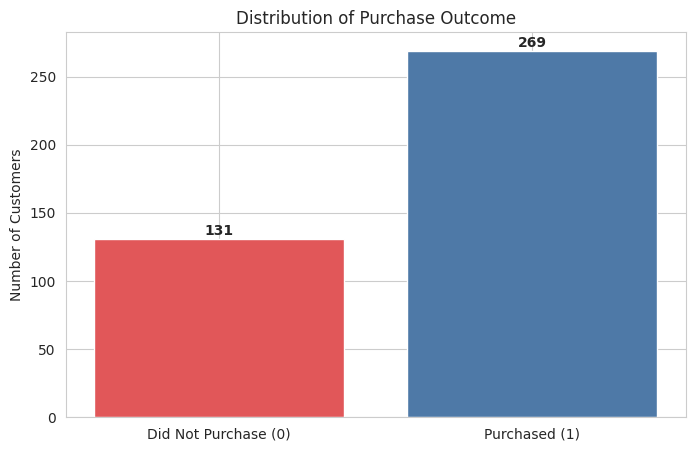

In [7]:
fig, ax = plt.subplots()
counts = dataset['Purchased'].value_counts().sort_index()
bars = ax.bar(['Did Not Purchase (0)', 'Purchased (1)'], counts.values, color=['#E15759', '#4E79A7'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, str(val), ha='center', fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Purchase Outcome')
plt.show()

#### 3.2 Visualization — Feature Distributions by Purchase Outcome

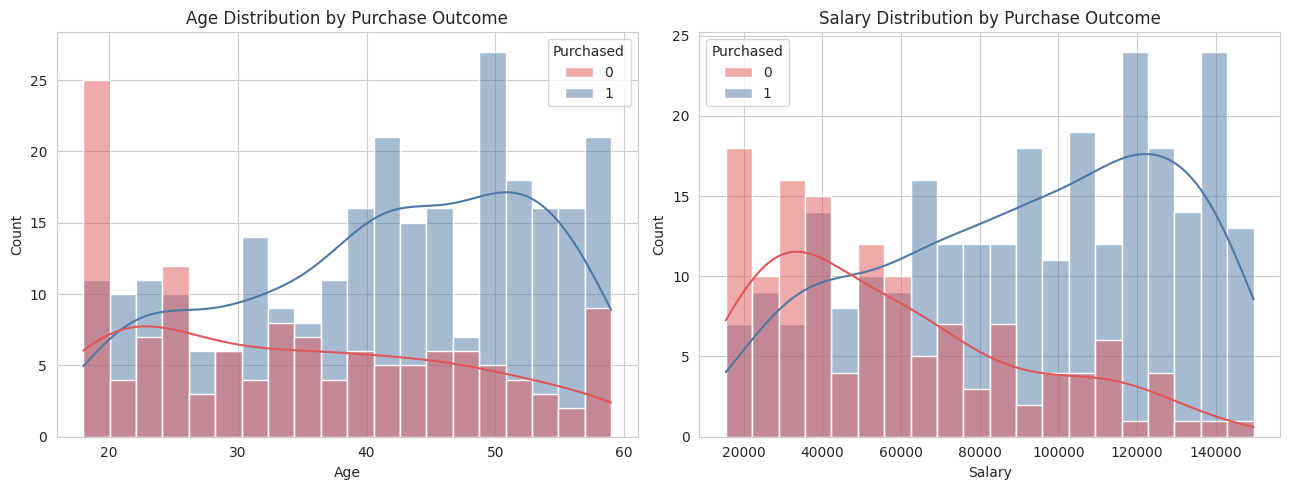

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=dataset, x='Age', hue='Purchased', kde=True, bins=20, ax=axes[0], palette=['#E15759', '#4E79A7'])
axes[0].set_title('Age Distribution by Purchase Outcome')

sns.histplot(data=dataset, x='Salary', hue='Purchased', kde=True, bins=20, ax=axes[1], palette=['#E15759', '#4E79A7'])
axes[1].set_title('Salary Distribution by Purchase Outcome')

plt.tight_layout()
plt.show()

#### 3.3 Visualization — Age vs. Salary Scatter Plot

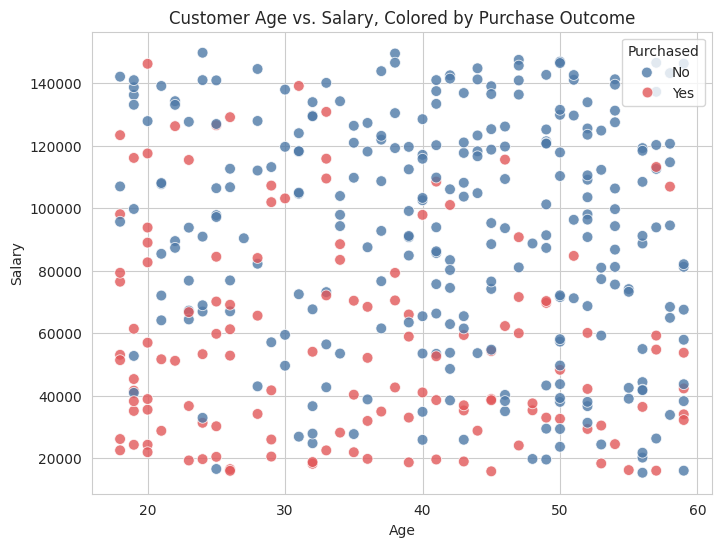

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = sns.scatterplot(
    data=dataset, x='Age', y='Salary', hue='Purchased',
    palette=['#E15759', '#4E79A7'], alpha=0.8, s=60, ax=ax
)
ax.set_title('Customer Age vs. Salary, Colored by Purchase Outcome')
ax.legend(title='Purchased', labels=['No', 'Yes'])
plt.show()

#### 3.4 Visualization — Correlation Heatmap

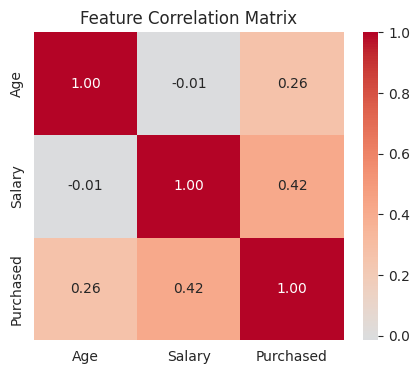

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.show()

### 4. Segregate Dataset into X (Features) & Y (Target)

In [11]:
X = dataset.iloc[:, :-1].values   # Age, Salary
Y = dataset.iloc[:, -1].values    # Purchased

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (400, 2)
Y shape: (400,)


### 5. Splitting Dataset into Train & Test

We use `stratify=Y` so the train and test sets preserve the same proportion of purchasers/non-purchasers as the full dataset — important since the classes are imbalanced.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0, stratify=Y
)

print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train size: 300 | Test size: 100


### 6. Feature Scaling

We scale features so Age and Salary (which are on very different numeric scales) contribute equally to distance-based and gradient-based models. We `fit_transform` on the training data only, then `transform` the test data using those same parameters — keeping the test set as an unseen, unbiased evaluation set.

In [13]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

### 7. Train & Compare Multiple Models

Rather than relying on a single algorithm, we train several common classifiers and compare them on the same test set. This gives a more complete picture of what works best for this data.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=0),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=0),
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=0),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

print('All models trained.')

All models trained.


### 8. Evaluate All Models

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, model in fitted_models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.81,0.785714,0.985075,0.874172
1,SVM (RBF Kernel),0.77,0.744444,1.000000,0.853503
2,Random Forest,0.77,0.814286,0.850746,0.832117
3,KNN (k=5),0.76,0.802817,0.850746,0.826087
4,Decision Tree,0.72,0.800000,0.776119,0.787879


#### 8.1 Visualization — Model Comparison Bar Chart

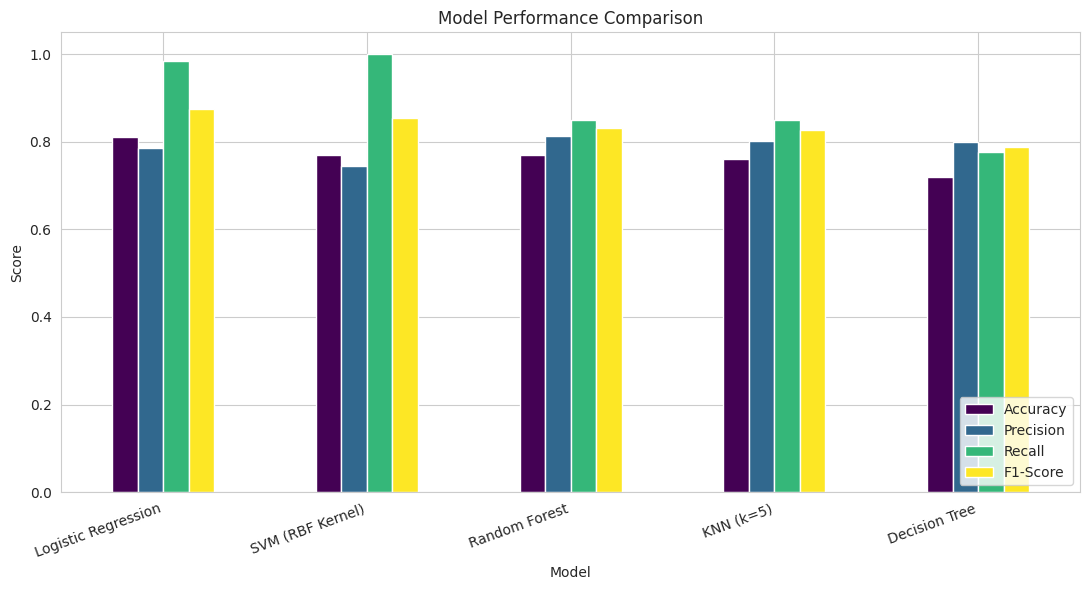

In [16]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plot_df = results_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(11, 6))
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 9. Select Best Model & Examine Confusion Matrix

We pick the model with the highest F1-score (a balance between precision and recall) as our best performer.

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print(f'Best model: {best_model_name}')

y_pred_best = best_model.predict(X_test_scaled)

Best model: Logistic Regression


#### 9.1 Visualization — Confusion Matrix Heatmap

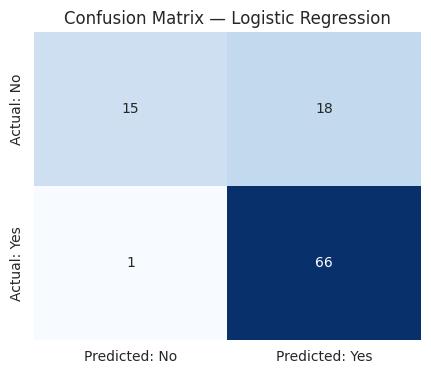

Accuracy of the Model: 81.00%


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes'], ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.show()

print('Accuracy of the Model: {0:.2f}%'.format(accuracy_score(y_test, y_pred_best) * 100))

#### 9.2 Visualization — ROC Curves for All Models

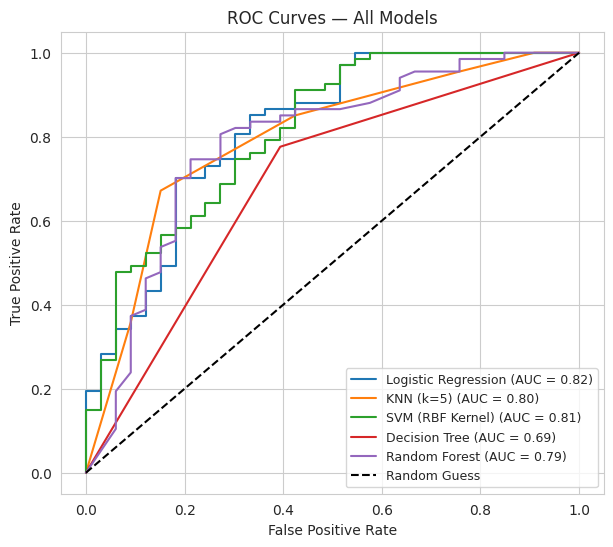

In [19]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in fitted_models.items():
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        scores = model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.show()

### 10. Visualize the Decision Boundary

Since we only have two features (Age and Salary), we can directly plot the regions the best model classifies as "will purchase" vs. "won't purchase", with the actual training points overlaid.

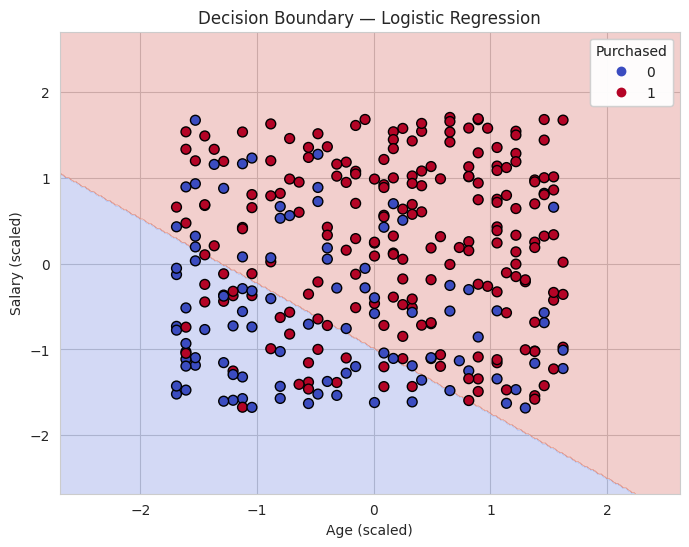

In [20]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
scatter = ax.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, cmap='coolwarm', edgecolor='k', s=50
)
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Salary (scaled)')
ax.set_title(f'Decision Boundary — {best_model_name}')
legend1 = ax.legend(*scatter.legend_elements(), title='Purchased')
ax.add_artist(legend1)
plt.show()

### 11. Feature Importance / Coefficients

For Logistic Regression, the coefficients tell us how strongly (and in which direction) each scaled feature pushes the prediction toward "will purchase". For tree-based models, we look at feature importances instead.

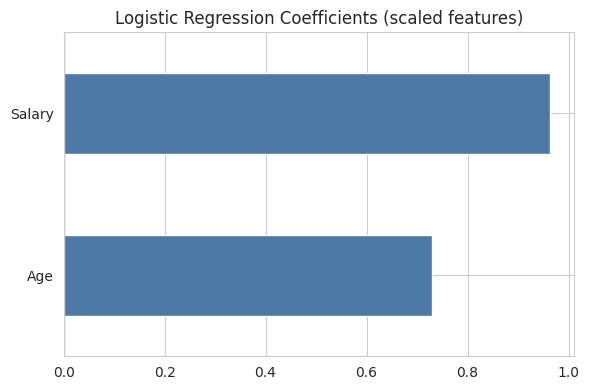

In [21]:
feature_names = ['Age', 'Salary']

if best_model_name == 'Logistic Regression':
    importance = pd.Series(best_model.coef_[0], index=feature_names)
    title = 'Logistic Regression Coefficients (scaled features)'
elif hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_names)
    title = f'{best_model_name} Feature Importances'
else:
    importance = None
    print(f'{best_model_name} does not expose simple feature importances.')

if importance is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    importance.sort_values().plot(kind='barh', ax=ax, color='#4E79A7')
    ax.set_title(title)
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

### 12. Predict for a New Customer

Enter an age and salary below to get a live prediction from the best model. (Set `INTERACTIVE = True` to be prompted for input; otherwise it predicts for the example values provided.)

In [22]:
# Take input from user

age = int(input("Enter Customer Age: "))
salary = int(input("Enter Customer Salary: "))

# Create input array
new_customer = [[age, salary]]

# Apply same scaling used during training
new_customer_scaled = sc.transform(new_customer)

# Predict
prediction = best_model.predict(new_customer_scaled)

# Probability (if supported)
if hasattr(best_model, 'predict_proba'):
    probability = best_model.predict_proba(new_customer_scaled)[0][1]
    print(f"\nPurchase Probability: {probability:.2%}")

# Final result
if prediction[0] == 1:
    print("\nPrediction: Customer WILL Purchase the Product")
else:
    print("\nPrediction: Customer WILL NOT Purchase the Product")

Enter Customer Age: 50
Enter Customer Salary: 52000

Purchase Probability: 70.60%

Prediction: Customer WILL Purchase the Product


### 13. Final Classification Report

In [23]:
from sklearn.metrics import classification_report

print(f'Classification Report — {best_model_name}\n')
print(classification_report(y_test, y_pred_best, target_names=['Did Not Purchase', 'Purchased']))

Classification Report — Logistic Regression

                  precision    recall  f1-score   support

Did Not Purchase       0.94      0.45      0.61        33
       Purchased       0.79      0.99      0.87        67

        accuracy                           0.81       100
       macro avg       0.86      0.72      0.74       100
    weighted avg       0.84      0.81      0.79       100



### Summary

- We compared five classification algorithms and selected the best performer based on F1-score, which balances precision and recall — more informative than accuracy alone on an imbalanced dataset.
- The decision boundary plot shows visually how Age and Salary combine to separate likely purchasers from non-purchasers.
- ROC/AUC comparison gives a threshold-independent view of each model's discriminative power.
- Next steps could include hyperparameter tuning (`GridSearchCV`), cross-validation for more robust estimates, and collecting more features (e.g., browsing history, prior purchases) to improve predictive power.